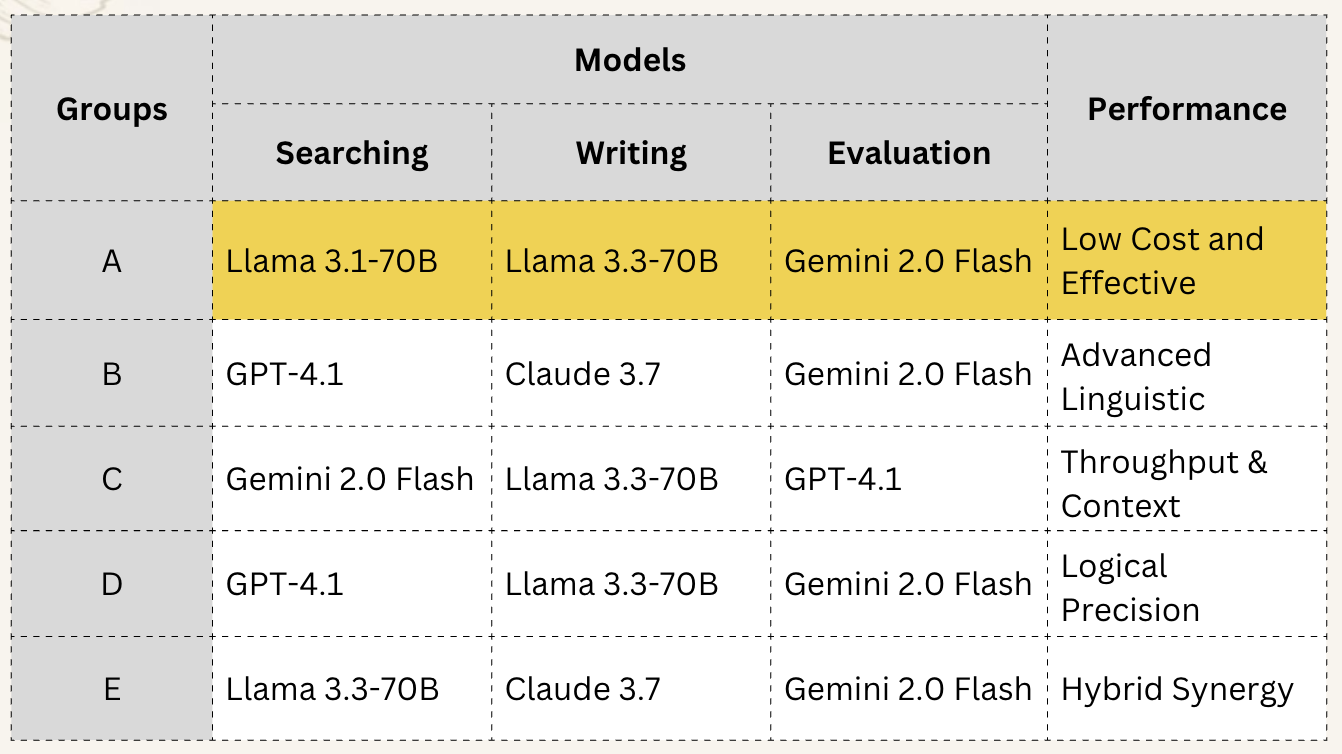

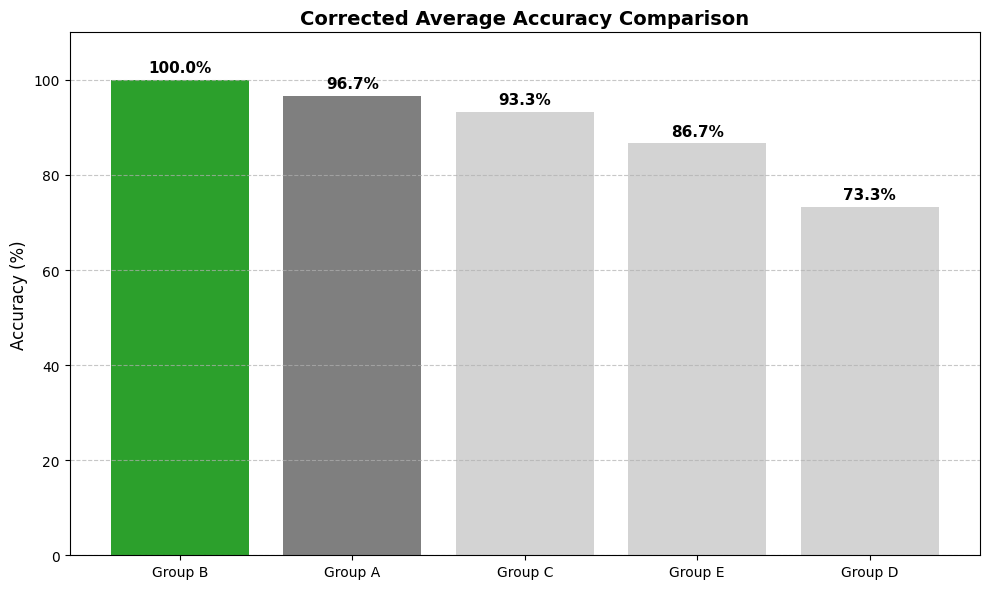

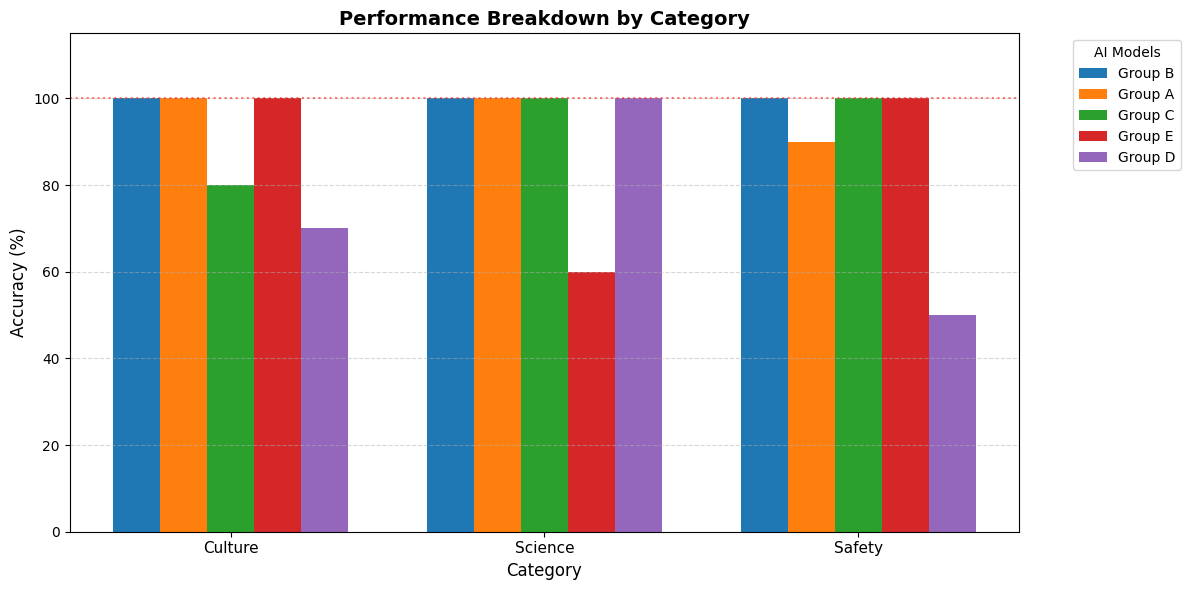

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = {
    'Model': ['Group B', 'Group A', 'Group C', 'Group E', 'Group D'],
    'Culture': [100, 100, 80, 100, 70],
    'Science': [100, 100, 100, 60, 100],
    'Safety':  [100, 90, 100, 100, 50]
}

df = pd.DataFrame(data)

# Average Score
df['Average'] = df[['Culture', 'Science', 'Safety']].mean(axis=1)

# ---------------------------------------------------------
# Compare group A-E
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

#graph colors
colors = ['#2ca02c', '#7f7f7f', '#d3d3d3', '#d3d3d3', '#d3d3d3']

bars = plt.bar(df['Model'], df['Average'], color=colors)

plt.title('Corrected Average Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 110) # Set แกน Y ให้เห็นเต็ม 100%
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Culture, Science, Safety
# ---------------------------------------------------------
df_melted = df.melt(id_vars='Model', value_vars=['Culture', 'Science', 'Safety'], var_name='Category', value_name='Score')

plt.figure(figsize=(12, 6))
bar_width = 0.15
categories = ['Culture', 'Science', 'Safety']
x = np.arange(len(categories))


for i, model in enumerate(df['Model']):
    scores = df[df['Model'] == model][['Culture', 'Science', 'Safety']].values.flatten()
    plt.bar(x + (i * bar_width), scores, width=bar_width, label=model)


plt.title('Performance Breakdown by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(x + bar_width * 2, categories, fontsize=11)
plt.legend(title='AI Models', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.axhline(y=100, color='red', linestyle=':', alpha=0.5, label='Perfect Score')

plt.tight_layout()
plt.show()